<a href="https://colab.research.google.com/github/xtianu/Docencia/blob/main/UT/Test/Tirana_CV_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision - Tirana May 2026
# Final Evaluation Exercise: Complete the following exercises

Remember to send your solution to my email: christian.mata@upc.edu


In [31]:
# IMPORTSSSSSSSSS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as sk

from sklearn.cluster import KMeans

## 1. Load and visualize the 'coins' image from the skimage built-in datasets. Report the size of the image and range of the pixel grayscale levels.

Size of the image: (303, 384)
Min pixel value: 1
Max pixel value: 252
Range: 251


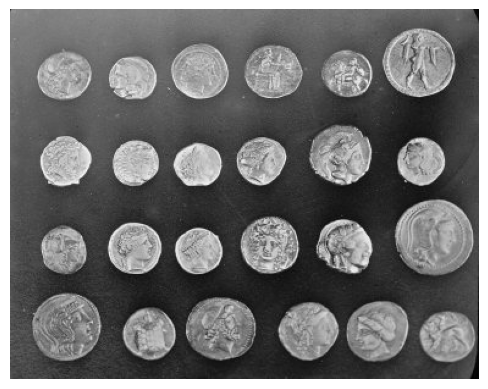

In [14]:
coins = sk.data.coins()
print(f"Size of the image: {coins.shape}")
print(f"Min pixel value: {coins.min()}")
print(f"Max pixel value: {coins.max()}")
print(f"Range: {coins.max() - coins.min()}")
plt.imshow(coins, cmap='gray')
plt.axis("off")
plt.show()

## 2. Represent the histogram of the image. Explain the peaks of the histogram in terms of regions of the image.

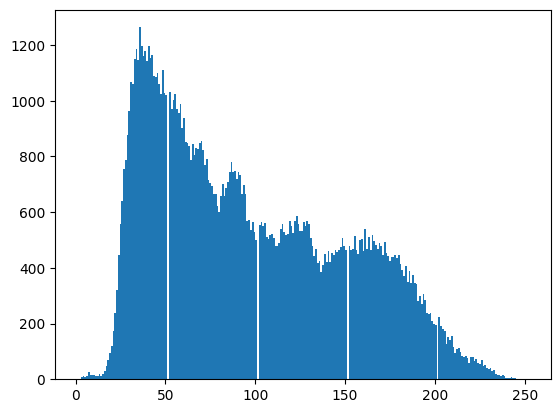

The histogram is somewhat right skewed and has a main peak at around 30 in pixel value. 
There are smaller peaks around 80, 120, and 170. 
This corresponds with the layout of the image as each coin is about the same color and cast similar shadows across the image.


In [16]:
coins_flattened = coins.flatten()
plt.hist(coins_flattened, bins=256, density=False)
plt.show()
print("The histogram is somewhat right skewed and has a main peak at around 30 in pixel value. \nThere are smaller peaks around 80, 120, and 170. \nThis corresponds with the layout of the image as each coin is about the same color and cast similar shadows across the image.")

## 3. Applied noise to the image and use the correct function to erase the noise.

I will use a Gaussian filter to reduce noise.
The Gaussian filter blurs with a weighted average kernel, so it should help.
I am too lazy to add titles.
But the top one is noisy and the bottom one is smoothed with Gaussian


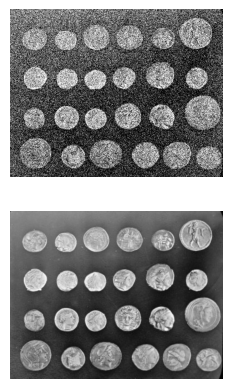

In [30]:
print("I will use a Gaussian filter to reduce noise.")
print("The Gaussian filter blurs with a weighted average kernel, so it should help.")
print("I am too lazy to add titles.")
print("But the top one is noisy and the bottom one is smoothed with Gaussian")

coins_noisy = sk.util.random_noise(coins, var=0.05)

coins_gauss_smoothed = sk.filters.gaussian(coins,0.5)

fig, axs = plt.subplots(2)

axs[0].imshow(coins_noisy, cmap='gray')
axs[0].axis('off')
axs[1].imshow(coins_gauss_smoothed, cmap='gray')
axs[1].axis('off')

plt.show()

## 4. Segment the image using a k-means clustering algorithm with k=2 and represent the result

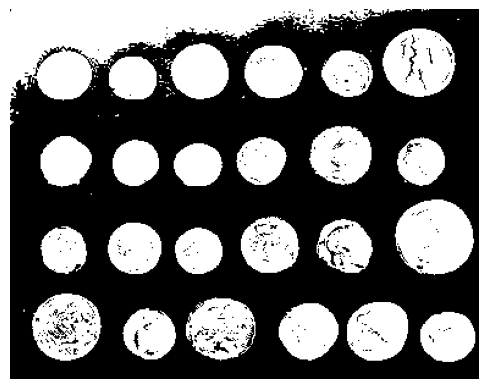

In [44]:
coins_reshaped = coins.reshape(-1,1)

kmeans = KMeans(n_clusters=2, random_state=0).fit(coins_reshaped)

coins_kmeans = kmeans.predict(coins_reshaped)

coins_kmeans_reshaped = np.reshape(coins_kmeans, coins.shape)

plt.imshow(coins_kmeans_reshaped, cmap='gray')
plt.axis('off')
plt.show()

## 5. Label the objects found in the image. Generate a figure with the original image and the labeled image. How many coins are there in the image?

Below is the plot with the original and labeled image.
There are 24 coins but 96 labeled regions
If I have time I will come back and try to make this better with exposure corrections.


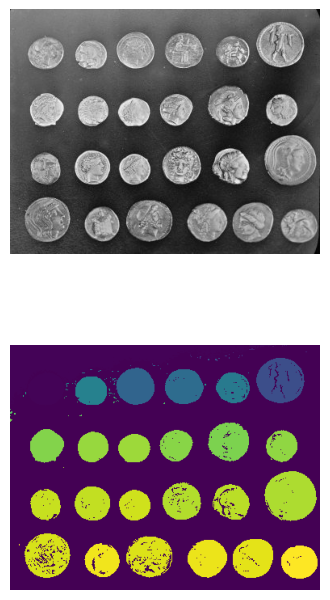

In [81]:
thresh = sk.filters.threshold_otsu(coins)

bw = coins > thresh

coins_label, nregions = sk.measure.label(bw, return_num=True)

fig, axs = plt.subplots(2,figsize=(4,8))
axs[0].axis('off')
axs[1].axis('off')

axs[0].imshow(coins,cmap='gray')
axs[1].imshow(coins_label)

print("Below is the plot with the original and labeled image.")
print(f"There are 24 coins but {nregions} labeled regions")
print("If I have time I will come back and try to make this better with exposure corrections.")

plt.show()

## 6. Extract the area, major axis length and orientation of each coin. Report the average values of the extracted features. Represent a scatterplot of the area vs major axis length.  

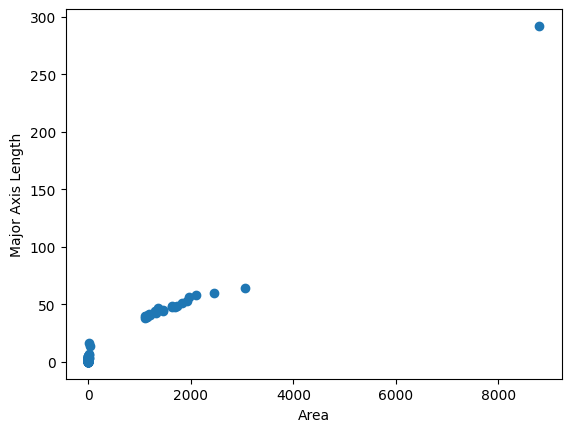

Below is the series with the mean of each feature.


Region              47.500000
Area               469.968750
MajorAxisLength     15.758364
Orientation         -0.160804
dtype: float64

In [90]:
props = sk.measure.regionprops(coins_label)
features = {
    "Region": list(range(nregions)),
    "Area": [prop.area for prop in props],
    "MajorAxisLength": [prop.axis_major_length for prop in props],
    "Orientation": [prop.orientation for prop in props]
}

df_features = pd.DataFrame(features)

plt.scatter(df_features["Area"], df_features["MajorAxisLength"])
plt.xlabel("Area")
plt.ylabel("Major Axis Length")
plt.show()

print("Below is the series with the mean of each feature.")
df_features.mean()

## 7. Using the labeled regions from the 'coins' image, how can I filter the regions to find those with an area greater than 1750 pixels, count how many such coins there are?

##8. Generate a 3-panel figure with the original image, the image with the little coins < 1750 coins (red color) and an image with the big coins > 1750 (blue color).

## 9. Describe the main steps required to perform  segmentation of an RGB image using an unsupervised clustering algorithm (use other algorithms different than K-Means and compare the results)

## 10. Extract the main texture features of this image

## Personal discussion

Provide a thoughtful reflection on the Computer Vision course, including your perspective on the knowledge you have acquired and your opinion about the professor. (Thank you very much for your feedback!)